<a href="https://colab.research.google.com/github/khanrimsha5009-dev/MACHINE-LEARING/blob/main/Copy_of_Project_3_ipynb_warisha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
sp = pd.read_csv(r"C:\Users\WARIS\Downloads\GoogleStockPriceTest (3).csv")

In [ ]:
sp.shape

(20, 6)

In [ ]:
sp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    20 non-null     object 
 1   Open    20 non-null     float64
 2   High    20 non-null     float64
 3   Low     20 non-null     float64
 4   Close   20 non-null     float64
 5   Volume  20 non-null     object 
dtypes: float64(4), object(2)
memory usage: 1.1+ KB


In [ ]:
sp.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2017,778.81,789.63,775.80,786.14,"1,657,300"
1,1/4/2017,788.36,791.34,783.16,786.90,"1,073,000"
2,1/5/2017,786.08,794.48,785.02,794.02,"1,335,200"
3,1/6/2017,795.26,807.90,792.20,806.15,"1,640,200"
4,1/9/2017,806.40,809.97,802.83,806.65,"1,272,400"


In [ ]:
#Data Cleaning (Removing Errors)
sp['Volume'] = sp['Volume'].str.replace(',', '').astype(float)

sp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    20 non-null     object 
 1   Open    20 non-null     float64
 2   High    20 non-null     float64
 3   Low     20 non-null     float64
 4   Close   20 non-null     float64
 5   Volume  20 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.1+ KB


In [ ]:
#checking the null values
print(sp.isnull().sum())

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [ ]:
#from null value if exists
sp= sp.dropna()

In [ ]:
#Remove Outliers (IQR Method)
Q1 = sp[['Open','High','Low','Close','Volume']].quantile(0.25)
Q3 = sp[['Open','High','Low','Close','Volume']].quantile(0.75)

IQR = Q3 - Q1

sp = sp[~((sp[['Open','High','Low','Close','Volume']] < (Q1 - 1.5 * IQR)) |
              (sp[['Open','High','Low','Close','Volume']] > (Q3 + 1.5 * IQR))).any(axis=1)]

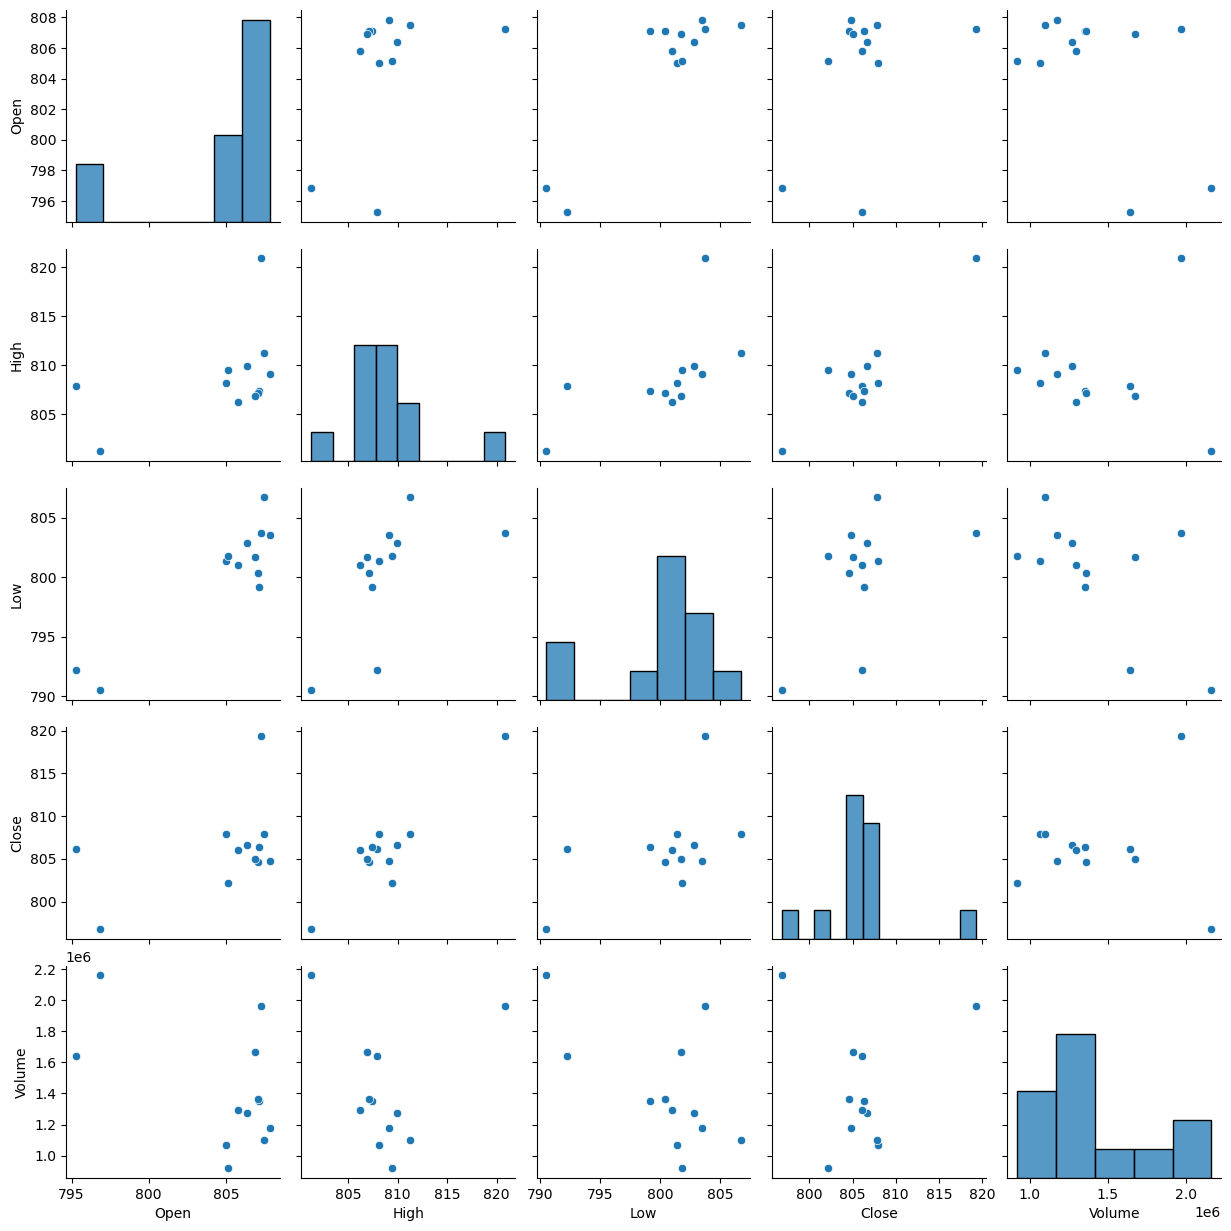

In [ ]:
sns.pairplot(sp[['Open','High','Low','Close','Volume']])
plt.show()

In [ ]:
#Predicting Close price
X = sp[['Open','High','Low','Volume']]
y = sp['Close']

In [ ]:
#spilting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#applying linear regression model
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#making predictions
y_pred = model.predict(X_test)

In [ ]:
#model evaluation
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: -2.50873977445137
RMSE: 12.150183175008152


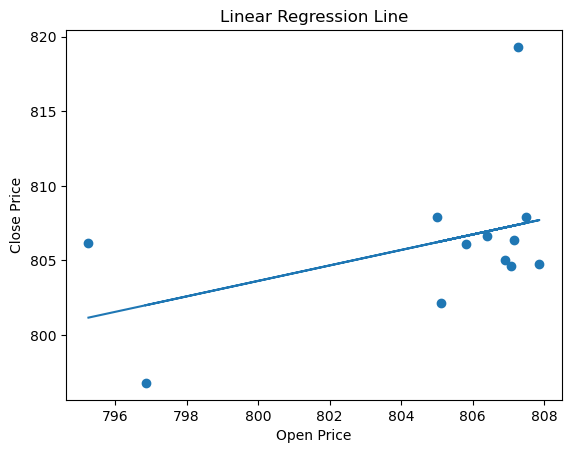

In [ ]:
X = sp[['Open']]
y = sp['Close']
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)
plt.scatter(sp['Open'], sp['Close'])

plt.plot(sp['Open'], model.predict(X))

plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Linear Regression Line")

plt.show()

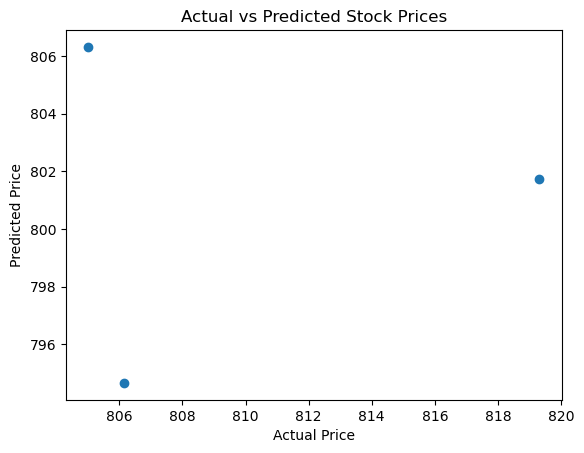

In [ ]:
#actual and predicted value visualization
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Stock Prices")

plt.show()